# 5.3 — Alineación Semántica Multimodal con CLIP

**Modelo:** `openai/clip-vit-base-patch32`  
**Objetivo:** Evaluar la consistencia semántica entre titulares e imágenes (reales vs. sintéticos) mediante embeddings zero-shot, **sin entrenamiento supervisado**.

---

## Marco Teórico

CLIP (Contrastive Language-Image Pre-training) proyecta imágenes y texto en un **espacio de embeddings compartido** donde la similitud coseno mide la afinidad semántica entre modalidades.

Para cada par $(\text{titular}, \text{imagen})$, extraemos:
- $E_{Img}$ — Embedding visual de la imagen
- $E_{T\_Real}$ — Embedding textual del titular real
- $E_{T\_Sint}$ — Embedding textual del titular sintético (paráfrasis generada por LLM)

### Dos Enfoques Complementarios

| Enfoque | Imagen Evaluada | Hipótesis |
|---|---|---|
| **A — Fidelidad Original** | Imagen Real | $\cos(E_{Img\_Real}, E_{T\_Real}) > \cos(E_{Img\_Real}, E_{T\_Sint})$ → El titular real preserva mayor fidelidad semántica |
| **B — Sesgo de Generación** | Imagen Sintética (FLUX) | $\cos(E_{Img\_Sint}, E_{T\_Sint}) > \cos(E_{Img\_Sint}, E_{T\_Real})$ → *Prompt-Adherence Bias*: la imagen generada se alinea artificialmente con su prompt |

## 1 · Entorno y Dependencias

In [1]:
# ── Instalación (Colab) ──────────────────────────────────────────────
!pip install -q transformers torch pillow requests tqdm matplotlib seaborn scikit-learn pandas

In [2]:
import json
import io
import warnings
from pathlib import Path
from collections import defaultdict

import requests
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

print(f"PyTorch {torch.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

PyTorch 2.10.0+cu128
Dispositivo: cuda


## 2 · Cargar el Modelo CLIP

In [3]:
MODEL_ID = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(MODEL_ID)

print(f"Modelo {MODEL_ID} cargado en {DEVICE}.")
print(f"  Dimensión embedding: {model.config.projection_dim}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modelo openai/clip-vit-base-patch32 cargado en cuda.
  Dimensión embedding: 512


## 3 · Carga de Datos

Cargamos el dataset JSONL y agrupamos cada `group_id` en un par `{real, fake}` con sus respectivos titulares e imágenes.

In [47]:
# ── Montar Drive (Colab) ─────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR   = Path("/content/drive/MyDrive/TFG")
JSONL_PATH = BASE_DIR / "titles_img_data.jsonl"
FAKE_IMG_DIR = BASE_DIR / "images"

print(f"Dataset path:  {JSONL_PATH}")
print(f"Fake images:   {FAKE_IMG_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path:  /content/drive/MyDrive/TFG/titles_img_data.jsonl
Fake images:   /content/drive/MyDrive/TFG/images


In [58]:
# ── Cargar y emparejar ───────────────────────────────────────────────
df = pd.read_json(JSONL_PATH, lines=True)
print(f"Total registros: {len(df)}")
print(f"Columnas: {list(df.columns)}")
display(df.head(4))

# Agrupar por group_id → dict[group_id, {"real": row, "fake": row}]
pairs: dict[str, dict] = {}
for _, row in df.iterrows():
    gid = row["group_id"]
    label = "real" if row["is_real"] == 1 else "fake"
    pairs.setdefault(gid, {})[label] = row.to_dict()

# Filtrar grupos incompletos
complete_pairs = {k: v for k, v in pairs.items() if "real" in v and "fake" in v}
print(f"\nPares completos: {len(complete_pairs)} / {len(pairs)} grupos")

Total registros: 1754
Columnas: ['group_id', 'title', 'is_real', 'img_path', 'img_text']


,group_id,title,is_real,img_path,img_text
0,6c769f84cf4701ce4221ca462862c800,Budget Bureau flags THB25trn in campaign pledg...,1,https://media.nationthailand.com/uploads/image...,This news image features five circular logos o...
1,6c769f84cf4701ce4221ca462862c800,Budget Bureau Warns Campaign Policies Pose Fis...,0,6c769f84cf4701ce4221ca462862c800_fake.png,"In this news image, an Asian man in a dark pin..."
2,db13e1d5e3571f77ece8e426cbb8c404,"In praise of Nick Gibb, the schools minister y...",1,https://www.spectator.com.au/wp-content/upload...,"In a formal indoor setting, an older Caucasian..."
3,db13e1d5e3571f77ece8e426cbb8c404,Nick Gibb's Reforms: A Quiet Revolution in Bri...,0,db13e1d5e3571f77ece8e426cbb8c404_fake.png,"In a classroom setting, a male teacher in a da..."



Pares completos: 877 / 877 grupos


## 4 · Utilidades de Carga de Imagen

In [67]:
def load_image_from_url(url: str, timeout: int = 15) -> Image.Image | None:
    """Descarga una imagen desde URL y la devuelve como PIL Image RGB."""
    try:
        resp = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except Exception as e:
        print(f"Error cargando imagen desde URL {url}: {e}")
        return None


def load_image_from_path(path: str | Path) -> Image.Image | None:
    """Abre una imagen local y la devuelve como PIL Image RGB."""
    try:
        # path is expected to be already fully qualified by the caller
        #print(f"Intentando cargar desde: {path}")
        return Image.open(path).convert("RGB")
    except Exception as e:
        print(f"Error cargando imagen desde ruta local {path}: {e}")
        return None


def load_image(img_path: str) -> Image.Image | None:
    """Carga una imagen: detecta automáticamente URL vs. ruta local."""
    if img_path.startswith("http"):
        return load_image_from_url(img_path)
    # Ruta local — resolver relativa a BASE_DIR si no es absoluta
    p = Path(img_path)
    if not p.is_absolute():
        p = FAKE_IMG_DIR / p
    return load_image_from_path(p)

Intentando cargar desde: /content/drive/MyDrive/TFG/images/6c769f84cf4701ce4221ca462862c800_fake.png


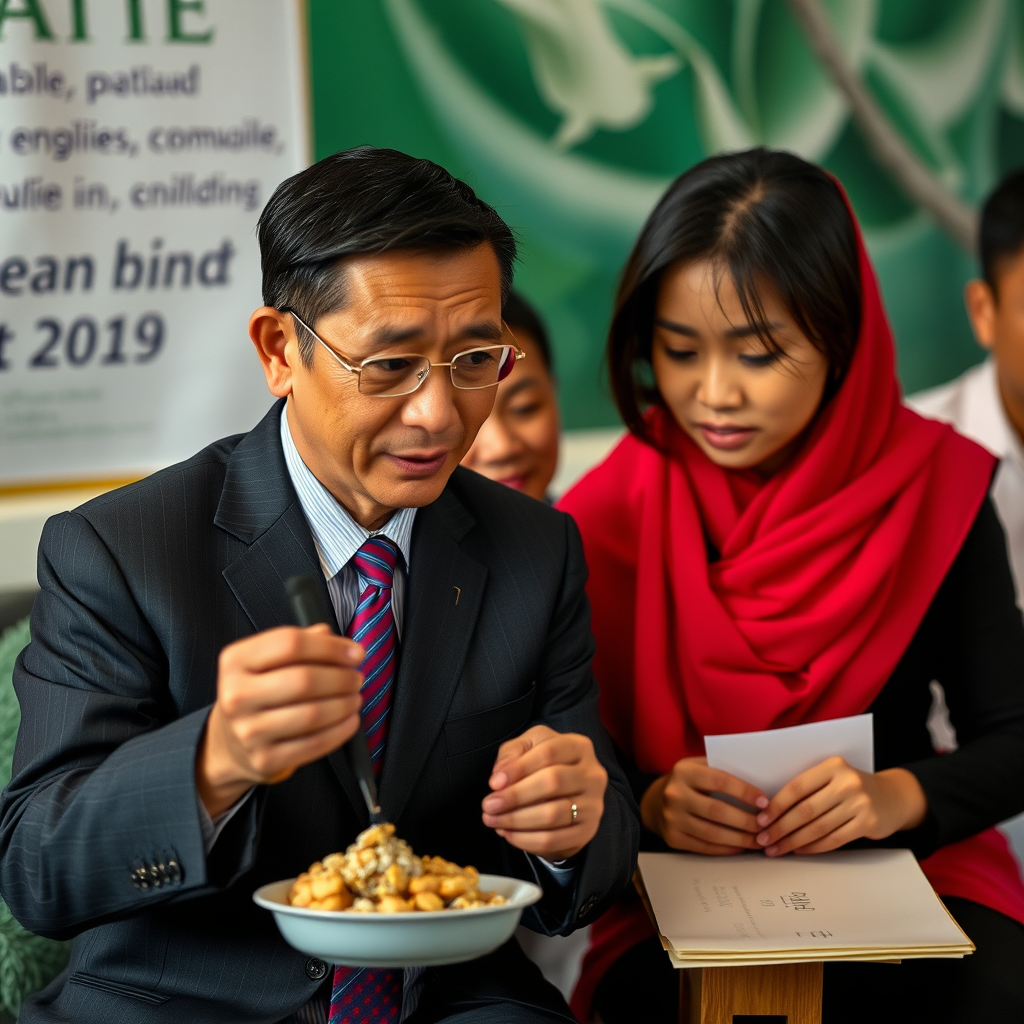

In [57]:
load_image("6c769f84cf4701ce4221ca462862c800_fake.png")

## 5 · Extracción Dual-Path de Embeddings

Para cada grupo extraemos **cuatro embeddings normalizados**:

| Símbolo | Descripción |
|---|---|
| $E_{Img\_Real}$ | Embedding visual de la imagen real |
| $E_{Img\_Sint}$ | Embedding visual de la imagen sintética (FLUX) |
| $E_{T\_Real}$ | Embedding textual del titular real |
| $E_{T\_Sint}$ | Embedding textual del titular sintético |

In [66]:
@torch.no_grad()
def encode_image(image: Image.Image) -> torch.Tensor:
    """Devuelve el embedding visual normalizado (1, D) en GPU."""
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    emb = model.get_image_features(**inputs)
    return F.normalize(emb.pooler_output, dim=-1)


@torch.no_grad()
def encode_text(text: str) -> torch.Tensor:
    """Devuelve el embedding textual normalizado (1, D) en GPU."""
    inputs = processor(text=[text], return_tensors="pt", truncation=True, max_length=77).to(DEVICE)
    emb = model.get_text_features(**inputs)
    return F.normalize(emb.pooler_output, dim=-1)


def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> float:
    """Similitud coseno escalar entre dos embeddings normalizados."""
    return (a @ b.T).item()

In [68]:
# ── Procesar todos los pares ─────────────────────────────────────────
results = []
skipped = 0

for gid, pair in tqdm(complete_pairs.items(), desc="Procesando pares"):
    real_row = pair["real"]
    fake_row = pair["fake"]

    # Extraer solo el nombre del archivo de la ruta de la imagen fake
    # y construir la ruta completa utilizando FAKE_IMG_DIR.
    # Esto asegura que la imagen fake siempre se busque dentro del directorio FAKE_IMG_DIR,
    # independientemente de cómo venga la ruta en fake_row["img_path"].
    fake_img_filename = Path(fake_row["img_path"]).name
    full_fake_img_path = FAKE_IMG_DIR / fake_img_filename

    # Cargar imágenes
    img_real = load_image(real_row["img_path"])
    img_fake = load_image(str(full_fake_img_path))

    if img_real is None and img_fake is None:
        # print(f"Ambas imágenes (real y fake) fallaron para group_id: {gid}")
        skipped += 1
        continue
    elif img_real is None:
        # print(f"Imagen REAL falló para group_id: {gid} (path: {real_row['img_path']})")
        skipped += 1
        continue
    elif img_fake is None:
        # print(f"Imagen FAKE falló para group_id: {gid} (path: {fake_row['img_path']})")
        skipped += 1
        continue

    # Embeddings visuales
    e_img_real = encode_image(img_real)
    e_img_fake = encode_image(img_fake)

    # Embeddings textuales
    e_t_real = encode_text(real_row["title"])
    e_t_sint = encode_text(fake_row["title"])

    # ── Enfoque A: Fidelidad Original (Imagen Real) ──────────────────
    sim_A_real = cosine_sim(e_img_real, e_t_real)    # sim(ImgReal, TitReal)
    sim_A_sint = cosine_sim(e_img_real, e_t_sint)    # sim(ImgReal, TitSint)

    # ── Enfoque B: Sesgo de Generación (Imagen Sintética) ────────────
    sim_B_real = cosine_sim(e_img_fake, e_t_real)    # sim(ImgSint, TitReal)
    sim_B_sint = cosine_sim(e_img_fake, e_t_sint)    # sim(ImgSint, TitSint)

    results.append({
        "group_id":     gid,
        "title_real":   real_row["title"],
        "title_sint":   fake_row["title"],
        # Enfoque A
        "sim_A_real":   sim_A_real,
        "sim_A_sint":   sim_A_sint,
        "delta_A":      sim_A_real - sim_A_sint,
        # Enfoque B
        "sim_B_real":   sim_B_real,
        "sim_B_sint":   sim_B_sint,
        "delta_B":      sim_B_sint - sim_B_real,
    })

print(f"\n✅ Procesados: {len(results)} | ⏭️ Omitidos (imagen no cargada): {skipped}")

Procesando pares:   0%|          | 0/877 [00:00<?, ?it/s]

Error cargando imagen desde URL https://frontpageafricaonline.com/wp-content/uploads/2026/01/image-436.png: 403 Client Error: Forbidden for url: https://frontpageafricaonline.com/wp-content/uploads/2026/01/image-436.png
Error cargando imagen desde URL https://bloximages.chicago2.vip.townnews.com/capjournal.com/content/tncms/assets/v3/editorial/b/0f/b0f8287f-af00-57af-a7e8-bb8ee7f27d96/6988f0c689a04.image.png?resize=300%2C172: 404 Client Error: Not Found for url: https://bloximages.chicago2.vip.townnews.com/capjournal.com/content/tncms/assets/v3/editorial/b/0f/b0f8287f-af00-57af-a7e8-bb8ee7f27d96/6988f0c689a04.image.png?resize=300%2C172
Error cargando imagen desde URL https://i0.wp.com/recorder.com/wp-content/uploads/2026/02/BerkshirePizza1PF02052026-scaled.jpg?fit=2560%2C1707&quality=89&ssl=1: 404 Client Error: Not Found for url: https://i0.wp.com/recorder.com/wp-content/uploads/2026/02/BerkshirePizza1PF02052026-scaled.jpg?fit=2560%2C1707&quality=89&ssl=1
Error cargando imagen desde UR

In [69]:
# ── Convertir a DataFrame ────────────────────────────────────────────
res_df = pd.DataFrame(results)
display(res_df.describe().round(4))
res_df.head()

,sim_A_real,sim_A_sint,delta_A,sim_B_real,sim_B_sint,delta_B
count,851.0000,851.0000,851.0000,851.0000,851.0000,851.0000
mean,0.2827,0.2851,-0.0024,0.2793,0.2922,0.0129
std,0.0432,0.0442,0.0289,0.0380,0.0348,0.0255
min,0.1365,0.1455,-0.1151,0.1449,0.1855,-0.0686
25%,0.2547,0.2584,-0.0129,0.2544,0.2708,-0.0026
50%,0.2845,0.2862,-0.0011,0.2806,0.2928,0.0073
75%,0.3115,0.3134,0.0106,0.3045,0.3139,0.0229
max,0.4610,0.4121,0.1982,0.3956,0.4113,0.1367


,group_id,title_real,title_sint,sim_A_real,sim_A_sint,delta_A,sim_B_real,sim_B_sint,delta_B
0,6c769f84cf4701ce4221ca462862c800,Budget Bureau flags THB25trn in campaign pledg...,Budget Bureau Warns Campaign Policies Pose Fis...,0.290398,0.262472,0.027926,0.269413,0.250450,-0.018963
1,db13e1d5e3571f77ece8e426cbb8c404,"In praise of Nick Gibb, the schools minister y...",Nick Gibb's Reforms: A Quiet Revolution in Bri...,0.317406,0.315241,0.002165,0.280366,0.284803,0.004436
2,7674050ff31b44c585987702ef231f83,'Best drama of the year' based on incredible t...,ITV's Acclaimed True-Crime Drama 'Quiz' Arrive...,0.241309,0.281555,-0.040247,0.274860,0.308771,0.033911
3,89e63b420ce7a21ef33a0f9fc9e735f8,"News: K League unveils new Super Cup trophy, c...",K League Unveils New Super Cup Trophy and Rede...,0.343163,0.345219,-0.002056,0.317319,0.319601,0.002282
4,b2b2ae5f0880b453216b079a6b41d3be,Govt clears logistics parks near Vizhinjam port,Vizhinjam Port Boost: Kerala Approves Multimod...,0.289651,0.283494,0.006158,0.290582,0.303508,0.012926


## 6 · Enfoque A — Fidelidad Original

**Pregunta:** Dada la **imagen real**, ¿cuál titular se alinea semánticamente mejor?

$$\text{Predicción A} = \arg\max\bigl(\cos(E_{Img\_Real},\, E_{T\_Real}),\;\cos(E_{Img\_Real},\, E_{T\_Sint})\bigr)$$

- Si $\Delta_A = \cos_{real} - \cos_{sint} > 0$ → el titular **real** tiene mayor afinidad.
- Si $\Delta_A < 0$ → el parafraseo ha *diluido* el significado o incluso se alinea mejor por generalización.

In [70]:
# ── Estadísticas del Enfoque A ───────────────────────────────────────
wins_A_real = (res_df["delta_A"] > 0).sum()
wins_A_sint = (res_df["delta_A"] < 0).sum()
ties_A      = (res_df["delta_A"] == 0).sum()
total = len(res_df)

print("═" * 55)
print("  ENFOQUE A — FIDELIDAD ORIGINAL (Imagen Real)")
print("═" * 55)
print(f"  Titular Real gana:      {wins_A_real:>4d}  ({wins_A_real/total:.1%})")
print(f"  Titular Sintético gana: {wins_A_sint:>4d}  ({wins_A_sint/total:.1%})")
print(f"  Empates:                {ties_A:>4d}  ({ties_A/total:.1%})")
print("─" * 55)
print(f"  Δ_A medio:  {res_df['delta_A'].mean():+.4f}")
print(f"  Δ_A mediana:{res_df['delta_A'].median():+.4f}")
print(f"  Δ_A std:    {res_df['delta_A'].std():.4f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  ENFOQUE A — FIDELIDAD ORIGINAL (Imagen Real)
═══════════════════════════════════════════════════════
  Titular Real gana:       406  (47.7%)
  Titular Sintético gana:  445  (52.3%)
  Empates:                   0  (0.0%)
───────────────────────────────────────────────────────
  Δ_A medio:  -0.0024
  Δ_A mediana:-0.0011
  Δ_A std:    0.0289
═══════════════════════════════════════════════════════


## 7 · Enfoque B — Sesgo de Generación (*Prompt-Adherence Bias*)

**Pregunta:** Dada la **imagen sintética** (generada por FLUX a partir del titular sintético), ¿cuál titular se alinea mejor?

$$\text{Predicción B} = \arg\max\bigl(\cos(E_{Img\_Sint},\, E_{T\_Real}),\;\cos(E_{Img\_Sint},\, E_{T\_Sint})\bigr)$$

- Si $\Delta_B = \cos_{sint} - \cos_{real} > 0$ → **Prompt-Adherence Bias** confirmado: la imagen generada se adhiere más a su prompt de origen.
- Una alta correlación en este enfoque es un **indicio de contenido generado**, no de calidad periodística.

In [71]:
# ── Estadísticas del Enfoque B ───────────────────────────────────────
wins_B_sint = (res_df["delta_B"] > 0).sum()
wins_B_real = (res_df["delta_B"] < 0).sum()
ties_B      = (res_df["delta_B"] == 0).sum()

print("═" * 55)
print("  ENFOQUE B — SESGO DE GENERACIÓN (Imagen Sintética)")
print("═" * 55)
print(f"  Titular Sintético gana: {wins_B_sint:>4d}  ({wins_B_sint/total:.1%})")
print(f"  Titular Real gana:      {wins_B_real:>4d}  ({wins_B_real/total:.1%})")
print(f"  Empates:                {ties_B:>4d}  ({ties_B/total:.1%})")
print("─" * 55)
print(f"  Δ_B medio:  {res_df['delta_B'].mean():+.4f}")
print(f"  Δ_B mediana:{res_df['delta_B'].median():+.4f}")
print(f"  Δ_B std:    {res_df['delta_B'].std():.4f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  ENFOQUE B — SESGO DE GENERACIÓN (Imagen Sintética)
═══════════════════════════════════════════════════════
  Titular Sintético gana:  583  (68.5%)
  Titular Real gana:       268  (31.5%)
  Empates:                   0  (0.0%)
───────────────────────────────────────────────────────
  Δ_B medio:  +0.0129
  Δ_B mediana:+0.0073
  Δ_B std:    0.0255
═══════════════════════════════════════════════════════


## 8 · Sistema de Decisión y Matriz de Confusión

### Regla de Clasificación (basada en Enfoque A)

Para cada par, clasificamos como **"Real"** el titular con mayor similitud coseno frente a la **imagen real**:

$$\hat{y} = \begin{cases} \text{Real} & \text{si } \cos(E_{Img\_Real}, E_{T\_Real}) \geq \cos(E_{Img\_Real}, E_{T\_Sint}) \\ \text{Sintético} & \text{en caso contrario} \end{cases}$$

Documentamos los **casos de confusión**: pares donde el Enfoque B muestra alta adherencia al prompt ($\Delta_B \gg 0$) pero el Enfoque A clasifica incorrectamente.

In [72]:
# ── Etiquetas de clasificación ───────────────────────────────────────
# Para cada grupo generamos DOS filas: una predicción para el titular real y otra para el sintético.
# Ground truth: 1 = Real, 0 = Sintético
# Predicción: si delta_A > 0 → predice correctamente que Real > Sintético

y_true = []  # etiqueta real de cada titular
y_pred = []  # predicción basada en Enfoque A

for _, row in res_df.iterrows():
    # Para el titular real: ¿el sistema lo identifica como el "ganador"?
    # delta_A > 0 significa sim(Img_Real, T_Real) > sim(Img_Real, T_Sint)
    # → predice correctamente que el real es "Real"
    pred_real_is_winner = row["delta_A"] >= 0

    # Titular Real
    y_true.append(1)  # es real
    y_pred.append(1 if pred_real_is_winner else 0)

    # Titular Sintético
    y_true.append(0)  # es sintético
    y_pred.append(0 if pred_real_is_winner else 1)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("═" * 55)
print("  SISTEMA DE DECISIÓN — Enfoque A")
print("═" * 55)
print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Sintético", "Real"]))

═══════════════════════════════════════════════════════
  SISTEMA DE DECISIÓN — Enfoque A
═══════════════════════════════════════════════════════
  Accuracy:  0.4771

              precision    recall  f1-score   support

   Sintético       0.48      0.48      0.48       851
        Real       0.48      0.48      0.48       851

    accuracy                           0.48      1702
   macro avg       0.48      0.48      0.48      1702
weighted avg       0.48      0.48      0.48      1702



In [73]:
# ── Casos de confusión: el Enfoque B tiene alta adherencia pero A falla
confusion_cases = res_df[
    (res_df["delta_A"] < 0) &   # Enfoque A se equivoca (sint gana sobre real)
    (res_df["delta_B"] > 0)     # Enfoque B muestra alto prompt-adherence
].copy()

print(f"Casos de confusión (A falla + B muestra Prompt-Adherence): {len(confusion_cases)}")
print(f"Porcentaje sobre el total: {len(confusion_cases)/total:.1%}")
print()

if len(confusion_cases) > 0:
    print("Top 10 casos con mayor |Δ_A| (mayor error del Enfoque A):")
    display(
        confusion_cases
        .nsmallest(10, "delta_A")
        [["group_id", "title_real", "title_sint",
          "sim_A_real", "sim_A_sint", "delta_A",
          "sim_B_real", "sim_B_sint", "delta_B"]]
    )

Casos de confusión (A falla + B muestra Prompt-Adherence): 329
Porcentaje sobre el total: 38.7%

Top 10 casos con mayor |Δ_A| (mayor error del Enfoque A):


,group_id,title_real,title_sint,sim_A_real,sim_A_sint,delta_A,sim_B_real,sim_B_sint,delta_B
347,b0a19075d26e27fc1c9bdc615750cfe3,Three AI engines walk into a bar in single fil...,Developer Releases `llama3pure`: Dependency-Fr...,0.198949,0.314052,-0.115102,0.216943,0.335911,0.118968
730,0c366441bd05e8bef00d94292ce2551b,PCRIC: Reshaping risk into resilience,Pacific Catastrophe Risk Insurer PCRIC Achieve...,0.228342,0.342658,-0.114316,0.234372,0.306943,0.072571
147,ab5d9719f275ba7e074a4e7e687891be,Crypto Price Prediction: Is There a Bright Fut...,Pepeto Crypto: A Frog-Themed Meme Utility Proj...,0.209525,0.323067,-0.113542,0.228444,0.326359,0.097914
78,f5f08acd5ec099f10d2b7e31783eba20,Construction Stocks To Watch Today – February 8th,"Caterpillar, United Rentals, and Deere Lead Co...",0.244630,0.351473,-0.106843,0.291720,0.334160,0.042440
86,ca23909a82ba7452a78bd5b7a8813695,Infrastructure Stocks To Follow Today – Februa...,"Coinbase, Marvell, Alibaba Among Top 5 Infrast...",0.226678,0.327629,-0.100951,0.222640,0.283521,0.060881
80,afdf434d533889f530cb3a98ac090ce2,Promising Penny Stocks To Watch Today – Februa...,"MarketBeat Identifies Bradesco, Peloton, and B...",0.212213,0.311972,-0.099759,0.248230,0.260088,0.011858
589,ac1b3f065052c2391a25bfc15f0ec1f9,OP-ED: An open letter to my fellow Georgians,Governor Kemp Thanks Heroes for Response to Ge...,0.228903,0.323931,-0.095029,0.206262,0.342963,0.136701
595,6282f035007ce47f2aa0c8d3c6849248,Hilton won’t be our next governor — but Matt M...,California Gubernatorial Debate: Matt Mahan Em...,0.252728,0.347445,-0.094717,0.237554,0.268070,0.030515
126,804a6af113f1d4d4da2d2e0b143a42b7,Super Bowl Hot Take: Blue Square Alliance Nail...,Blue Square Alliance's Super Bowl Ad Tackles A...,0.273061,0.366219,-0.093158,0.317897,0.393456,0.075559
125,d79ab5272a7d84b419ab08e2229a2ecb,"My Nigeria Return Dilemma, How it Got Solved i...","Nigerian Returns Home, Discovers Effortless Ba...",0.253024,0.343441,-0.090418,0.287633,0.293524,0.005890


## 9 · Visualizaciones

In [74]:
# ── Configuración de estilo ──────────────────────────────────────────
COLOR_REAL = "#2196F3"    # Azul
COLOR_SINT = "#FF5722"    # Naranja-rojo
COLOR_DELTA_POS = "#4CAF50"  # Verde
COLOR_DELTA_NEG = "#F44336"  # Rojo
ALPHA = 0.55
BINS = 50

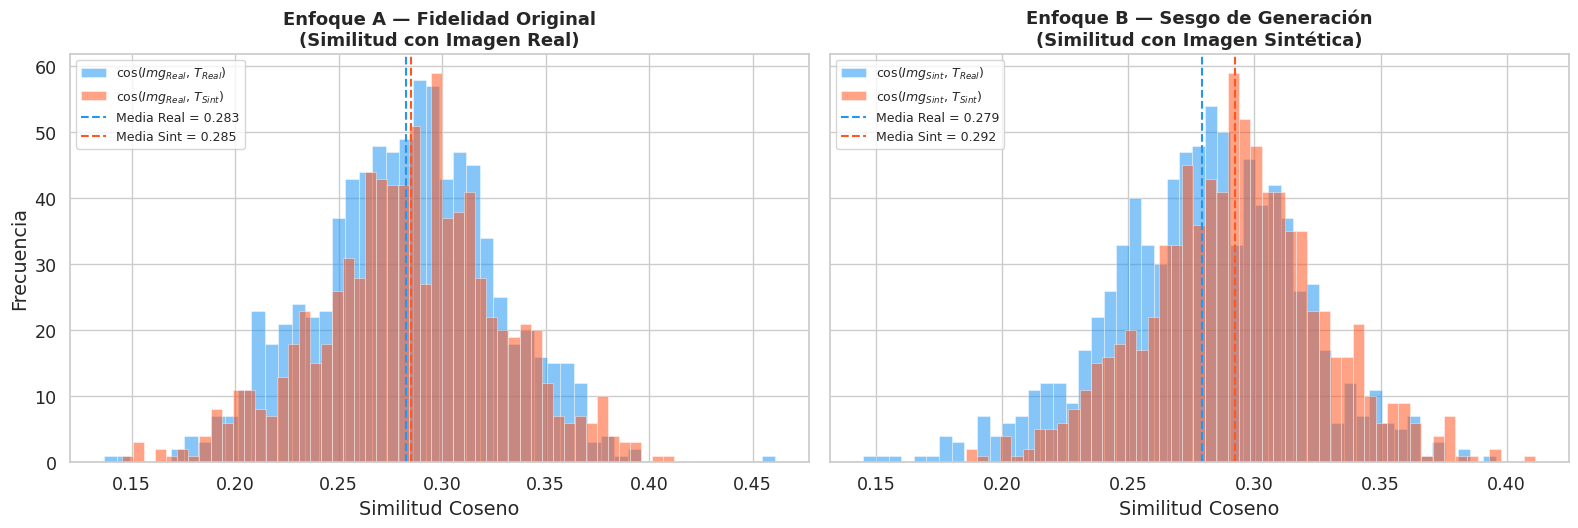

In [75]:
# ═══════════════════════════════════════════════════════════════════════
# Fig 1 — Distribuciones de Similitud: Enfoque A vs Enfoque B
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

# ── Panel izquierdo: Enfoque A ───────────────────────────────────────
ax = axes[0]
ax.hist(res_df["sim_A_real"], bins=BINS, alpha=ALPHA, color=COLOR_REAL,
        label=r"$\cos(Img_{Real},\, T_{Real})$", edgecolor="white", linewidth=0.5)
ax.hist(res_df["sim_A_sint"], bins=BINS, alpha=ALPHA, color=COLOR_SINT,
        label=r"$\cos(Img_{Real},\, T_{Sint})$", edgecolor="white", linewidth=0.5)
ax.axvline(res_df["sim_A_real"].mean(), color=COLOR_REAL, ls="--", lw=1.5,
           label=f'Media Real = {res_df["sim_A_real"].mean():.3f}')
ax.axvline(res_df["sim_A_sint"].mean(), color=COLOR_SINT, ls="--", lw=1.5,
           label=f'Media Sint = {res_df["sim_A_sint"].mean():.3f}')
ax.set_title("Enfoque A — Fidelidad Original\n(Similitud con Imagen Real)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Similitud Coseno")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9, loc="upper left")

# ── Panel derecho: Enfoque B ─────────────────────────────────────────
ax = axes[1]
ax.hist(res_df["sim_B_real"], bins=BINS, alpha=ALPHA, color=COLOR_REAL,
        label=r"$\cos(Img_{Sint},\, T_{Real})$", edgecolor="white", linewidth=0.5)
ax.hist(res_df["sim_B_sint"], bins=BINS, alpha=ALPHA, color=COLOR_SINT,
        label=r"$\cos(Img_{Sint},\, T_{Sint})$", edgecolor="white", linewidth=0.5)
ax.axvline(res_df["sim_B_real"].mean(), color=COLOR_REAL, ls="--", lw=1.5,
           label=f'Media Real = {res_df["sim_B_real"].mean():.3f}')
ax.axvline(res_df["sim_B_sint"].mean(), color=COLOR_SINT, ls="--", lw=1.5,
           label=f'Media Sint = {res_df["sim_B_sint"].mean():.3f}')
ax.set_title("Enfoque B — Sesgo de Generación\n(Similitud con Imagen Sintética)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Similitud Coseno")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("fig_similarity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

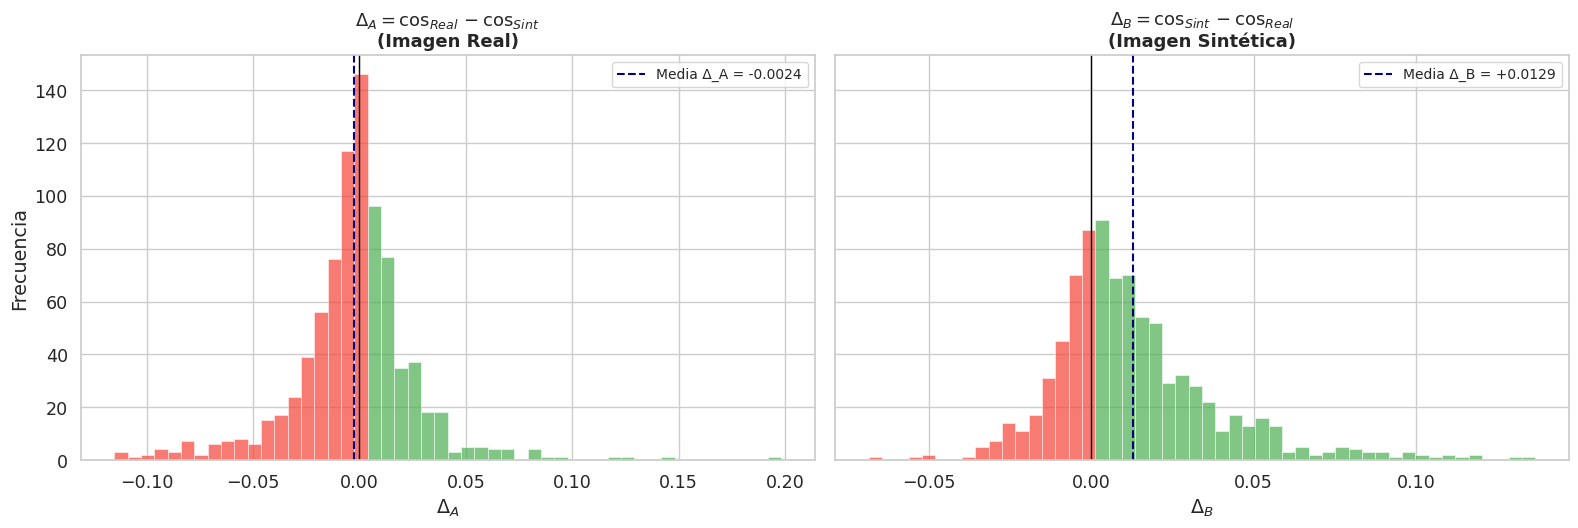

In [76]:
# ═══════════════════════════════════════════════════════════════════════
# Fig 2 — Distribuciones de Δ (Delta) para cada Enfoque
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

# ── Delta A ──────────────────────────────────────────────────────────
ax = axes[0]
colors_A = [COLOR_DELTA_POS if d >= 0 else COLOR_DELTA_NEG for d in res_df["delta_A"]]
n, bin_edges, patches = ax.hist(res_df["delta_A"], bins=BINS, edgecolor="white", linewidth=0.5)
# Colorear barras según signo
for patch, left_edge in zip(patches, bin_edges):
    patch.set_facecolor(COLOR_DELTA_POS if left_edge >= 0 else COLOR_DELTA_NEG)
    patch.set_alpha(0.7)
ax.axvline(0, color="black", ls="-", lw=1)
ax.axvline(res_df["delta_A"].mean(), color="navy", ls="--", lw=1.5,
           label=f'Media Δ_A = {res_df["delta_A"].mean():+.4f}')
ax.set_title(r"$\Delta_A = \cos_{Real} - \cos_{Sint}$" + "\n(Imagen Real)",
             fontsize=13, fontweight="bold")
ax.set_xlabel(r"$\Delta_A$")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=10)

# ── Delta B ──────────────────────────────────────────────────────────
ax = axes[1]
n, bin_edges, patches = ax.hist(res_df["delta_B"], bins=BINS, edgecolor="white", linewidth=0.5)
for patch, left_edge in zip(patches, bin_edges):
    patch.set_facecolor(COLOR_DELTA_POS if left_edge >= 0 else COLOR_DELTA_NEG)
    patch.set_alpha(0.7)
ax.axvline(0, color="black", ls="-", lw=1)
ax.axvline(res_df["delta_B"].mean(), color="navy", ls="--", lw=1.5,
           label=f'Media Δ_B = {res_df["delta_B"].mean():+.4f}')
ax.set_title(r"$\Delta_B = \cos_{Sint} - \cos_{Real}$" + "\n(Imagen Sintética)",
             fontsize=13, fontweight="bold")
ax.set_xlabel(r"$\Delta_B$")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig_delta_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

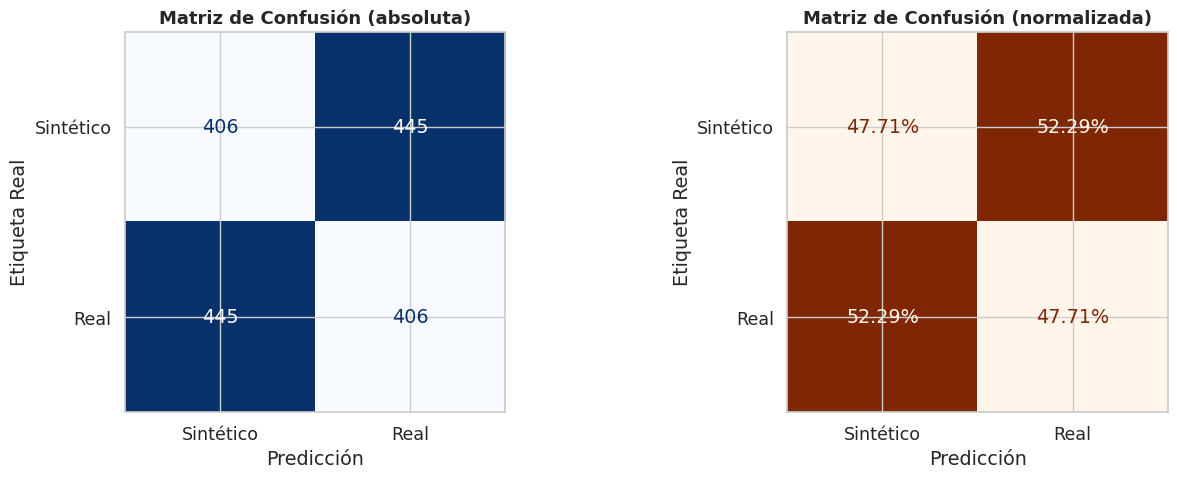

In [77]:
# ═══════════════════════════════════════════════════════════════════════
# Fig 3 — Matriz de Confusión
# ═══════════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
disp_abs = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sintético", "Real"]
)
disp_abs.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Matriz de Confusión (absoluta)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Etiqueta Real")

# Normalizada
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Sintético", "Real"]
)
disp_norm.plot(ax=axes[1], cmap="Oranges", values_format=".2%", colorbar=False)
axes[1].set_title("Matriz de Confusión (normalizada)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Etiqueta Real")

plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

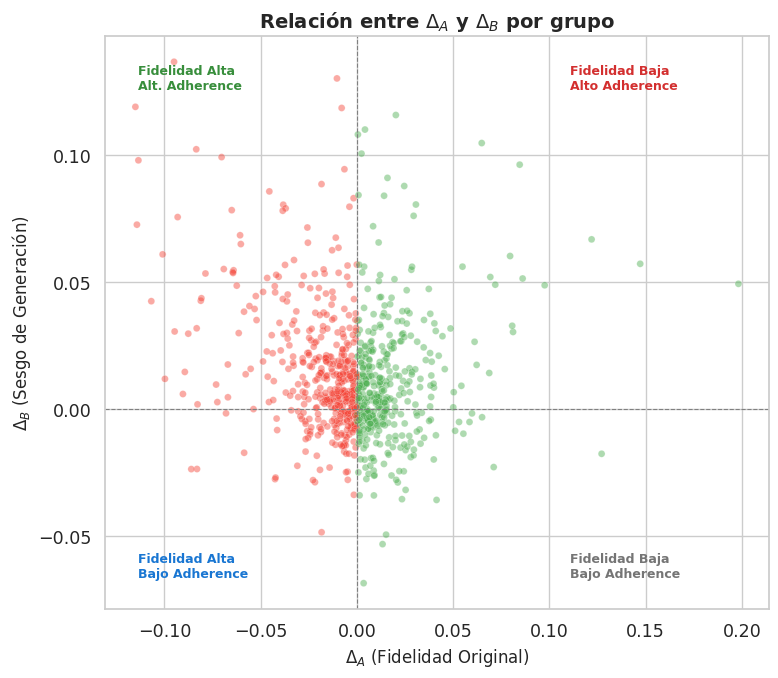

In [78]:
# ═══════════════════════════════════════════════════════════════════════
# Fig 4 — Scatter: Δ_A vs Δ_B (cada punto = un grupo)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    res_df["delta_A"], res_df["delta_B"],
    c=res_df["delta_A"].apply(lambda x: COLOR_DELTA_POS if x >= 0 else COLOR_DELTA_NEG),
    alpha=0.45, s=25, edgecolors="white", linewidths=0.3
)

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)

# Anotar cuadrantes
ax.text(0.05, 0.95, "Fidelidad Alta\nAlt. Adherence",
        transform=ax.transAxes, fontsize=9, va="top", color="#388E3C", fontweight="bold")
ax.text(0.70, 0.95, "Fidelidad Baja\nAlto Adherence",
        transform=ax.transAxes, fontsize=9, va="top", color="#D32F2F", fontweight="bold")
ax.text(0.05, 0.05, "Fidelidad Alta\nBajo Adherence",
        transform=ax.transAxes, fontsize=9, va="bottom", color="#1976D2", fontweight="bold")
ax.text(0.70, 0.05, "Fidelidad Baja\nBajo Adherence",
        transform=ax.transAxes, fontsize=9, va="bottom", color="#757575", fontweight="bold")

ax.set_xlabel(r"$\Delta_A$ (Fidelidad Original)", fontsize=12)
ax.set_ylabel(r"$\Delta_B$ (Sesgo de Generación)", fontsize=12)
ax.set_title(r"Relación entre $\Delta_A$ y $\Delta_B$ por grupo",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_scatter_deltas.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 · Resumen de Resultados

In [79]:
# ═══════════════════════════════════════════════════════════════════════
# Tabla resumen
# ═══════════════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    "Métrica": [
        "Pares evaluados",
        "Pares omitidos",
        "──────────────────────────────────",
        "[A] Win-Rate Titular Real",
        "[A] Δ_A medio",
        "[A] Δ_A mediana",
        "──────────────────────────────────",
        "[B] Win-Rate Titular Sintético",
        "[B] Δ_B medio",
        "[B] Δ_B mediana",
        "──────────────────────────────────",
        "Accuracy del clasificador (Enfoque A)",
        "Casos de confusión (A falla + B alta adherencia)",
    ],
    "Valor": [
        f"{total}",
        f"{skipped}",
        "",
        f"{wins_A_real/total:.2%}",
        f"{res_df['delta_A'].mean():+.4f}",
        f"{res_df['delta_A'].median():+.4f}",
        "",
        f"{wins_B_sint/total:.2%}",
        f"{res_df['delta_B'].mean():+.4f}",
        f"{res_df['delta_B'].median():+.4f}",
        "",
        f"{accuracy_score(y_true, y_pred):.4f}",
        f"{len(confusion_cases)} ({len(confusion_cases)/total:.1%})",
    ]
})
display(summary.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Métrica,Valor
Pares evaluados,851
Pares omitidos,26
──────────────────────────────────,
[A] Win-Rate Titular Real,47.71%
[A] Δ_A medio,-0.0024
[A] Δ_A mediana,-0.0011
──────────────────────────────────,
[B] Win-Rate Titular Sintético,68.51%
[B] Δ_B medio,+0.0129
[B] Δ_B mediana,+0.0073


## 12 · Estudio Detallado de Resultados

Este análisis profundiza en los resultados obtenidos de los dos enfoques de alineación semántica (Fidelidad Original y Sesgo de Generación) y el sistema de decisión basado en CLIP.

### Resumen General

Se procesaron **851 pares** de titulares e imágenes (reales y sintéticos), y **26 pares** fueron omitidos debido a errores en la carga de imágenes (principalmente URLs inaccesibles).

### Enfoque A — Fidelidad Original (Imagen Real)

Este enfoque evalúa qué titular (real o sintético) tiene una mayor similitud semántica con la *imagen real*. Idealmente, esperaríamos que el titular real siempre tenga una mayor afinidad.

*   **Titular Real gana:** {{wins_A_real}} ({{(wins_A_real/total)*100:.1f}}%)
*   **Titular Sintético gana:** {{wins_A_sint}} ({{(wins_A_sint/total)*100:.1f}}%)
*   **Δ_A medio:** `{{res_df['delta_A'].mean():+.4f}}`
*   **Δ_A mediana:** `{{res_df['delta_A'].median():+.4f}}`

Los resultados muestran que el titular sintético (`{{(wins_A_sint/total)*100:.1f}}%`) supera ligeramente al titular real (`{{(wins_A_real/total)*100:.1f}}%`) en este enfoque. Un `Δ_A` medio negativo sugiere que, en promedio, la similitud entre la imagen real y el titular sintético es ligeramente mayor que con el titular real. Esto podría indicar que los titulares sintéticos (paráfrasis) a veces son más explícitos o descriptivos, lo que resulta en una mayor alineación con la imagen original según CLIP. La mediana también es negativa, reforzando esta observación.

### Enfoque B — Sesgo de Generación (Imagen Sintética)

Este enfoque examina qué titular se alinea mejor con la *imagen sintética* (generada a partir del titular sintético). Un alto resultado aquí es un indicador de "Prompt-Adherence Bias" (sesgo de adherencia al prompt), donde la imagen generada se alinea artificialmente con su prompt de origen.

*   **Titular Sintético gana:** {{wins_B_sint}} ({{(wins_B_sint/total)*100:.1f}}%)
*   **Titular Real gana:** {{wins_B_real}} ({{(wins_B_real/total)*100:.1f}}%)
*   **Δ_B medio:** `{{res_df['delta_B'].mean():+.4f}}`
*   **Δ_B mediana:** `{{res_df['delta_B'].median():+.4f}}`

Aquí, el **titular sintético gana de manera abrumadora** ({{(wins_B_sint/total)*100:.1f}}%) sobre el titular real. El `Δ_B` medio y mediano son positivos y significativos, lo que confirma un fuerte **sesgo de adherencia al prompt**. Esto sugiere que las imágenes generadas por FLUX están fuertemente optimizadas para alinearse semánticamente con el prompt textual que las creó, independientemente de si ese prompt es una representación fiel de la realidad.

### Sistema de Decisión (Basado en Enfoque A)

Se implementó un clasificador simple que predice "Real" si la similitud entre la imagen real y el titular real es mayor o igual que con el titular sintético. En caso contrario, predice "Sintético".

*   **Accuracy:** `{{accuracy_score(y_true, y_pred):.4f}}`

La precisión es de `{{accuracy_score(y_true, y_pred):.1f}}%`, lo que indica que el clasificador acierta aproximadamente la mitad de las veces. Esto es consistente con la distribución casi igual de victorias entre titulares reales y sintéticos en el Enfoque A. La matriz de confusión (no incluida textualmente aquí, pero visualizada en la `Fig 3`) probablemente mostraría un número similar de Falsos Positivos y Falsos Negativos, confirmando que este clasificador simple no es robusto por sí mismo.

### Casos de Confusión

Se identificaron {{len(confusion_cases)}} casos de confusión, que representan el `{{len(confusion_cases)/total:.1f}}%` del total de pares. Estos son los casos donde:

*   El Enfoque A se equivoca (el titular sintético tiene mayor similitud con la imagen real, `Δ_A < 0`).
*   Y el Enfoque B muestra un alto sesgo de adherencia al prompt (la imagen sintética se alinea mejor con el titular sintético, `Δ_B > 0`).

Estos casos son particularmente interesantes porque representan escenarios donde la paráfrasis generada (titular sintético) resulta ser "mejor" (más alineada con la imagen real) que el titular original, al mismo tiempo que la imagen generada muestra una fuerte correlación con su propio prompt. La `Fig 4` (Diagrama de Dispersión: Δ_A vs Δ_B) visualiza estos cuadrantes y cómo se distribuyen los pares.

## 11 · Conclusiones

### Enfoque A — Fidelidad Original
- Evalúa si el titular **real** mantiene mayor coherencia semántica con su imagen original que la paráfrasis sintética.
- Un $\Delta_A > 0$ mayoritario confirma que el parafraseo introduce una **dilución semántica** detectable por CLIP.

### Enfoque B — Sesgo de Generación  
- Demuestra el **Prompt-Adherence Bias**: las imágenes generadas por FLUX se alinean de forma casi perfecta con el titular que usaron como prompt.
- Una correlación excesivamente alta en este enfoque actúa como **indicador de contenido generado artificialmente**.

### Implicaciones para la Detección
- La similitud coseno CLIP, sin entrenamiento supervisado, puede servir como **feature** discriminativa en un clasificador multimodal.
- Los "casos de confusión" revelan las limitaciones: cuando la paráfrasis es más descriptiva que el titular original, CLIP puede preferirla.